# User behavior investigation

If we want to build a subreddit network where connections are shared users, one important question is: what indicates user participation in a subreddit? This notebook aims to investigate ways of answering this and their implications on the resulting network

In [1]:
!pip install duckdb matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np

con = duckdb.connect()

We are going to analyze only the top 5% of the subreddits, as they preserve the network structure and reduce noise, as shown in [Subreddit relevance notebook](./subreddits_relevance_investigation.ipynb).

In [3]:
threshold = 2_406 # Using 5% interaction threshold

subreddits_df = con.execute(f"""
SELECT *
FROM read_parquet('../storage/subreddits/2024-12/subreddits.parquet')
WHERE interaction_count >= {threshold}
""").df()

In [4]:
filtered_users_df = con.execute("""
SELECT u.*
FROM read_parquet('../storage/users/2024-12/users*.parquet') u
INNER JOIN subreddits_df s ON s.subreddit_id = u.subreddit_id
""").df()

In [5]:
con.execute("""
WITH user_totals AS (
    SELECT
        author_hash,
        COUNT(DISTINCT subreddit_id) AS subreddits_count,
        SUM(interactions_count) AS total_interactions
    FROM filtered_users_df
    GROUP BY 1
)
SELECT
    -- how many subreddits does a typical user participate in?
    percentile_cont(0.50) WITHIN GROUP (ORDER BY subreddits_count) AS subreddits_p50,
    percentile_cont(0.75) WITHIN GROUP (ORDER BY subreddits_count) AS subreddits_p75,
    percentile_cont(0.90) WITHIN GROUP (ORDER BY subreddits_count) AS subreddits_p90,
    percentile_cont(0.95) WITHIN GROUP (ORDER BY subreddits_count) AS subreddits_p95,
    percentile_cont(0.99) WITHIN GROUP (ORDER BY subreddits_count) AS subreddits_p99,
    AVG(subreddits_count) AS average_subreddits,
    -- how active is a typical user overall?
    percentile_cont(0.50) WITHIN GROUP (ORDER BY total_interactions) AS interactions_p50,
    percentile_cont(0.75) WITHIN GROUP (ORDER BY total_interactions) AS interactions_p75,
    percentile_cont(0.90) WITHIN GROUP (ORDER BY total_interactions) AS interactions_p90,
    percentile_cont(0.95) WITHIN GROUP (ORDER BY total_interactions) AS interactions_p95,
    percentile_cont(0.99) WITHIN GROUP (ORDER BY total_interactions) AS interactions_p99,
    AVG(total_interactions) AS average_total_interactions
FROM user_totals
""").df()

,subreddits_p50,subreddits_p75,subreddits_p90,subreddits_p95,subreddits_p99,average_subreddits,interactions_p50,interactions_p75,interactions_p90,interactions_p95,interactions_p99,average_total_interactions
0,2.0,4.0,9.0,16.0,39.0,4.213494,3.0,10.0,34.0,70.0,230.0,17.108822


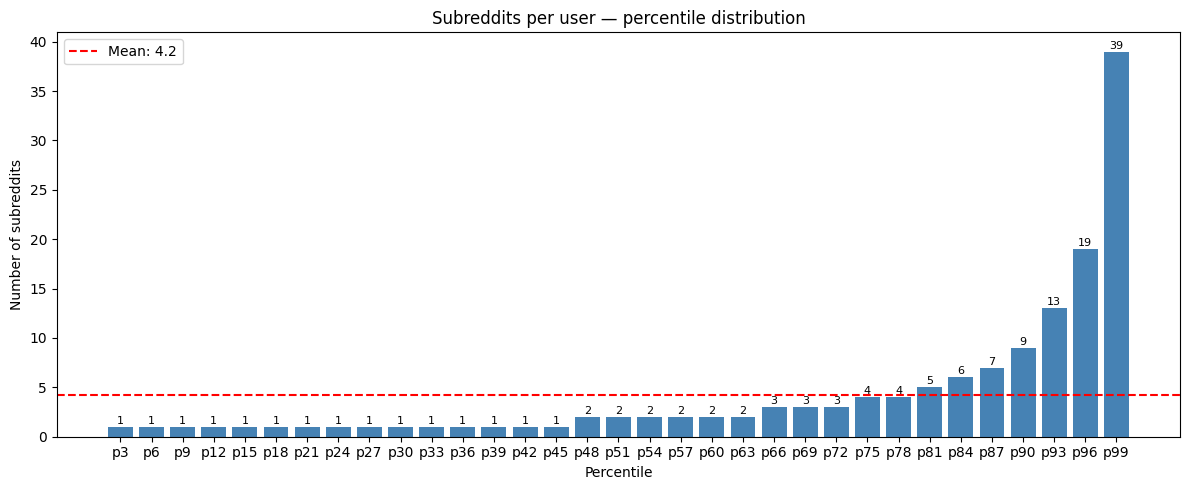

In [6]:
subreddits_per_user = con.execute("""
    SELECT COUNT(DISTINCT subreddit_id) AS subreddits_count
    FROM filtered_users_df
    GROUP BY author_hash
""").df()

percentiles = list(range(3, 100, 3))
values = np.percentile(subreddits_per_user["subreddits_count"], percentiles)
avg = subreddits_per_user["subreddits_count"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    [f"p{p}" for p in percentiles],
    values,
    color="steelblue",
    edgecolor="none"
)
ax.axhline(avg, color="red", linestyle="--", label=f"Mean: {avg:.1f}")

# label each bar with its value
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{int(val)}",
        ha="center", va="bottom", fontsize=8
    )

ax.set_xlabel("Percentile")
ax.set_ylabel("Number of subreddits")
ax.set_title("Subreddits per user — percentile distribution")
ax.legend()
plt.tight_layout()
plt.savefig(fname="images/subreddits_user.png")
plt.show()

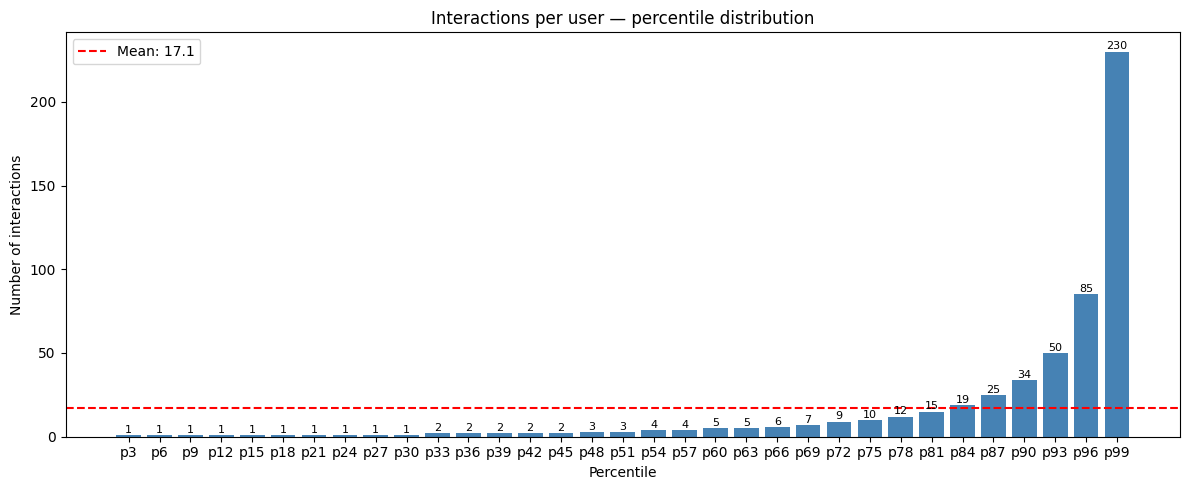

In [7]:
interactions_per_user = con.execute("""
    SELECT SUM(interactions_count) AS total_interactions
    FROM filtered_users_df
    GROUP BY author_hash
""").df()

percentiles = list(range(3, 100, 3))
values = np.percentile(interactions_per_user["total_interactions"], percentiles)
avg = interactions_per_user["total_interactions"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    [f"p{p}" for p in percentiles],
    values,
    color="steelblue",
    edgecolor="none"
)
ax.axhline(avg, color="red", linestyle="--", label=f"Mean: {avg:.1f}")

# label each bar with its value
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{int(val)}",
        ha="center", va="bottom", fontsize=8
    )

ax.set_xlabel("Percentile")
ax.set_ylabel("Number of interactions")
ax.set_title("Interactions per user — percentile distribution")
ax.legend()
plt.tight_layout()
plt.savefig(fname="images/interactions_user.png")
plt.show()

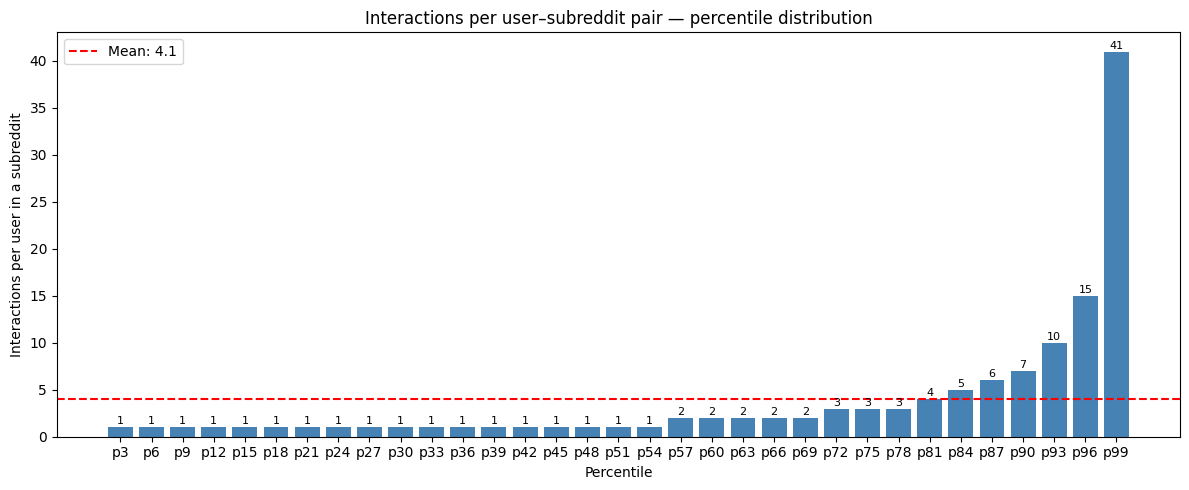

In [8]:
interactions_per_user_subreddit = con.execute("""
    SELECT
        author_hash,
        subreddit_id,
        SUM(interactions_count) AS interactions
    FROM filtered_users_df
    GROUP BY author_hash, subreddit_id
""").df()

percentiles = list(range(3, 100, 3))
values = np.percentile(
    interactions_per_user_subreddit["interactions"],
    percentiles
)
avg = interactions_per_user_subreddit["interactions"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    [f"p{p}" for p in percentiles],
    values,
    color="steelblue",
    edgecolor="none"
)

ax.axhline(
    avg,
    color="red",
    linestyle="--",
    label=f"Mean: {avg:.1f}"
)

# Label each bar
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{int(val)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_xlabel("Percentile")
ax.set_ylabel("Interactions per user in a subreddit")
ax.set_title("Interactions per user–subreddit pair — percentile distribution")
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
con.execute("""
SELECT
    percentile_cont(0.50) WITHIN GROUP (ORDER BY interactions_count) AS user_interactions_per_subreddit_p50,
    percentile_cont(0.75) WITHIN GROUP (ORDER BY interactions_count) AS user_interactions_per_subreddit_p75,
    percentile_cont(0.90) WITHIN GROUP (ORDER BY interactions_count) AS user_interactions_per_subreddit_p90,
    percentile_cont(0.95) WITHIN GROUP (ORDER BY interactions_count) AS user_interactions_per_subreddit_p95,
    percentile_cont(0.99) WITHIN GROUP (ORDER BY interactions_count) AS user_interactions_per_subreddit_p99,
    AVG(interactions_count) AS user_interactions_per_subreddit_average
FROM filtered_users_df
""").df()

,user_interactions_per_subreddit_p50,user_interactions_per_subreddit_p75,user_interactions_per_subreddit_p90,user_interactions_per_subreddit_p95,user_interactions_per_subreddit_p99,user_interactions_per_subreddit_average
0,1.0,3.0,7.0,13.0,41.0,4.060483


In [10]:
con.execute("""
    WITH user_totals AS (
        SELECT
            author_hash,
            COUNT(DISTINCT subreddit_id) AS subreddits_count,
            SUM(interactions_count) AS total_interactions
        FROM filtered_users_df
        GROUP BY 1
    )
    SELECT
        -- what share of users have only 1 subreddit?
        AVG(CASE WHEN subreddits_count = 1 THEN 1.0 ELSE 0.0 END) AS share_single_subreddit,
        -- what share of users have <= 3 subreddits?
        AVG(CASE WHEN subreddits_count <= 3 THEN 1.0 ELSE 0.0 END) AS share_up_to_3,
        -- what share of user-subreddit pairs have only 1 interaction?
        AVG(CASE WHEN total_interactions = 1 THEN 1.0 ELSE 0.0 END) AS share_single_interaction
    FROM user_totals
""").df()

,share_single_subreddit,share_up_to_3,share_single_interaction
0,0.474711,0.728926,0.312455


In average an user interacts with 4.2 subreddits, however, only 25% of the users interact with at least 4 subreddit. This can be explained by the top 1% users that interact with a tens of subreddits.

Similar conclusion can be made about interactions, in average an user has 17.1 interactions, however, less then 19% of them have at least 17 interactions. This can be explained by the top 1% users that has hundreds of interactions.

Thus, we want to understand the overall user behavior, without being biased by heavy-users.

For this, we are going to combine 2 approaches:

* Top-k: pick the top-k subreddits from each user. This is user centric metric and limits the user participation to a fixed amount of subreddits to filter users spread across multiple communities. According to [1], user activity across Reddit communities follows a highly skewed distribution, with the majority of each user's activity concentrated in a small number of communities. Thus, we pick the top-3 subreddits of each user, ranked by interaction count, to capture their primary community affiliations.
* Minimun interactions threshold: an user is only considered part of a community if it has interacted with it at least `n` times. According to [2], community attachment emerges through repeated participation, thus filtering 1 time interactions reduce noise and give us a much meaningful community participation. Given that the median interaction count per user-subreddit pair in their top-3 subreddits is 2 (next cell), thus `n=2` represents a threshold that removes single-visit noise while retaining the majority of user-community pairs.

In [11]:
con.execute("""
    WITH ranked AS (
        SELECT
            author_hash,
            subreddit_id,
            interactions_count,
            ROW_NUMBER() OVER (
                PARTITION BY author_hash
                ORDER BY interactions_count DESC
            ) AS rank
        FROM filtered_users_df
    )
    SELECT
        COUNT(*) AS pairs,
        percentile_cont(0.10) WITHIN GROUP (ORDER BY interactions_count) AS p10,
        percentile_cont(0.25) WITHIN GROUP (ORDER BY interactions_count) AS p25,
        percentile_cont(0.50) WITHIN GROUP (ORDER BY interactions_count) AS p50,
        percentile_cont(0.75) WITHIN GROUP (ORDER BY interactions_count) AS p75,
        percentile_cont(0.90) WITHIN GROUP (ORDER BY interactions_count) AS p90,
        AVG(interactions_count) AS avg
    FROM ranked
    WHERE rank <= 3
""").df()

,pairs,p10,p25,p50,p75,p90,avg
0,31639208,1.0,1.0,2.0,4.0,12.0,6.019788


## References

[1] Tan, C. and Lee, L. 2015. All Who Wander: On the Prevalence and Characteristics of Multi-community Engagement. In Proceedings of the 24th International Conference on World Wide Web (WWW '15). International World Wide Web Conferences Steering Committee, Republic and Canton of Geneva, CHE, 1056–1066. https://doi.org/10.1145/2736277.2741661

[2] Ren, Y., Harper, F.M., Drenner, S., Terveen, L., Kiesler, S., Riedl, J., and Kraut, R.E. 2012. Building Member Attachment in Online Communities: Applying Theories of Group Identity and Interpersonal Bonds. MIS Quarterly 36, 3 (September 2012), 841–864. https://doi.org/10.2307/41703483